# RANDOM FOREST TITANIC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic').dropna()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [3]:
df.isna().sum().sum()

0

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import graphviz


In [5]:
cols = ['pclass','sex','age','sibsp','parch','fare','embarked']
target = 'survived'
X = df[cols]
y = df[target]

In [6]:
X = pd.get_dummies(X,columns=['sex','embarked'],drop_first=True)

In [7]:
scaler = StandardScaler()
cols_numeric = ['age','sibsp','parch','fare']
X[cols_numeric] = scaler.fit_transform(X[cols_numeric])

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
model = RandomForestClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')


Accuracy : 0.70


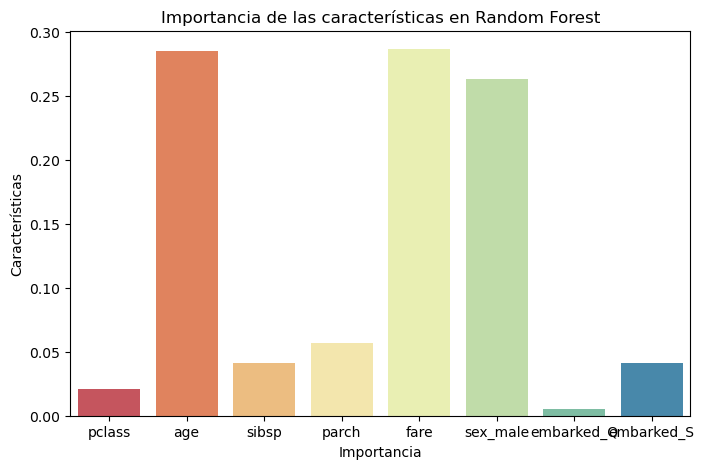

In [14]:
# Obtener importancia de las características
importances = model.feature_importances_
# Graficar
plt.figure(figsize=(8, 5))
sns.barplot(x=X.columns, y=importances,palette = 'Spectral',linewidth = 1)
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Importancia de las características en Random Forest")
plt.show()

C:\Users\ingma\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probab

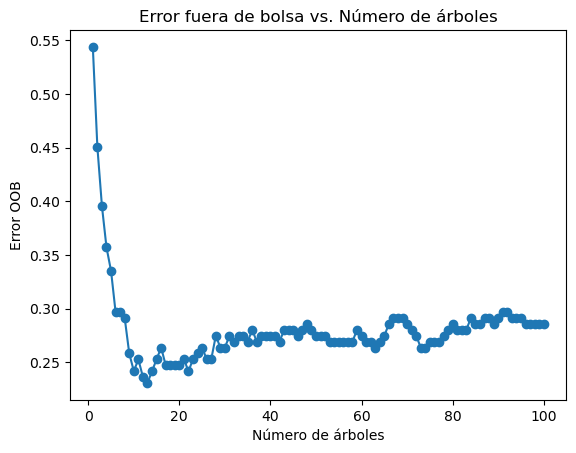

In [15]:
errors = []
for i in range(1, 101):
    model = RandomForestClassifier(n_estimators=i, random_state=42, oob_score=True)
    model.fit(X, y)
    errors.append(1 - model.oob_score_)

plt.plot(range(1, 101), errors, marker="o")
plt.xlabel("Número de árboles")
plt.ylabel("Error OOB")
plt.title("Error fuera de bolsa vs. Número de árboles")
plt.show()

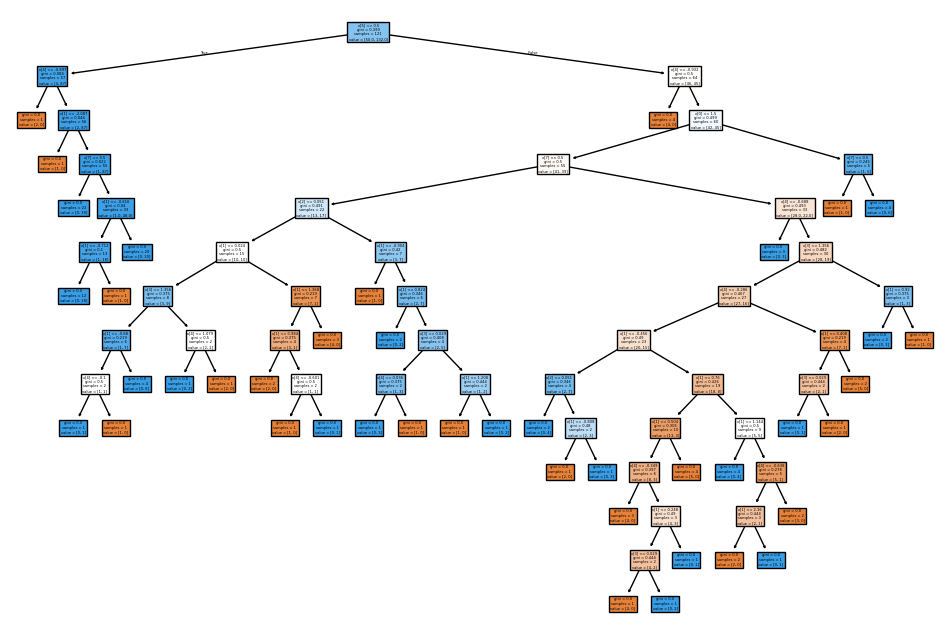

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(model.estimators_[0], filled=True)
plt.show()